# AP 155 Lab Exercise
---
## Exercise 6: Eigenfunctions and Eigenvalues of a Hamiltonian

_Instructions_: 
- **Problem 1 Report figure:** First 5 wavefunctions of the harmonic oscillator.
- **Problem 2 Report figure:** Energy analysis and plotting of probability density.
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: 
- _Student No._: 20XX-XXXXX
- _Section_: INPUT SECTION HERE

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

<!-- ### Report figure

<img src="figures/cat.jpg" alt="Alt text" width=45%> <img src="figures/cat.jpg" alt="Alt text" width=45%>


EDIT ME. See instruction above for what to include. Insert caption here, a short description what the figure illustrates. The syntax in markdown for putting a figure is `![Description](local_file_name.png)` or `<img src="/path/to_image.jpg" alt="Alt text" width=45%>`. Make sure the figure has complete elements.
-->

### Problem 1
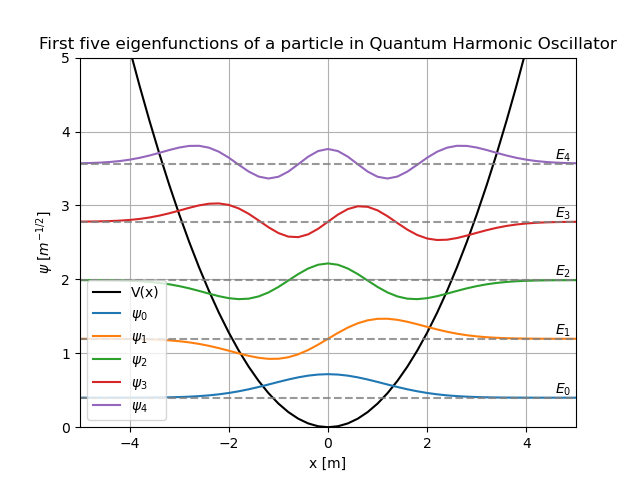

Figure 1

Figure 1 shows the first five eigenstates of a particle in the quantum harmonic oscillator. This was done by solving the time-independent Schrodinger equation as an eigenvalue problem. In order to do this computationally, the Hamiltonian was represented as a matrix by representing the potential energy operator as a diagonal matrix and the kinetic energy operator was derived using the central finite-difference method. The eigenvalue problem was solved using ```np.linalg.eigh()```. The function $f_n = E_n + \psi_n$ was plotted in order to show the shape of the wavefunction, and its associated energy. The ground state energy returned $E_0 = 0.40 [J]$, noting that the next energies increment by $E = \hbar\omega$. From what I learned in Physics 141, the wavefunctions start to decay under the potential (classically forbidden region), as well as n-nodes present for each $\psi_n$, which are shown aptly in the figure.

### Problem 2
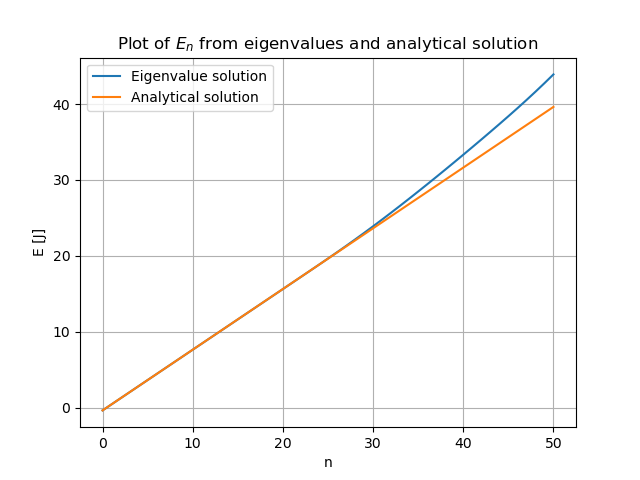

Figure 2

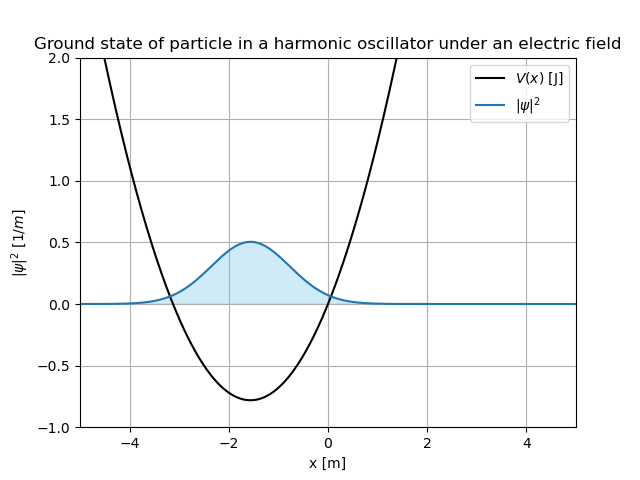

Figure 3

Figure 2 shows the comparison between numerically calculated energies as eigenenergies and the analytical solution. Observe that they closely match for lower energies, up until n = 30, the eigenvalue solution starts to diverge away. This is due to the bounds at which we solve for the eigenenergies ($x \in [-10, 10]$). This bounding compresses the wavefunction which overestimates the corresponding energy. Similarly, if the bounds were to be streched, say $x\in[-100,100]$, this stretches the wavefunction which understimates the corresponding energy.

Figure 3 shows what the ground state function looks like. This makes sense because the uniform electric field shifts the potential to the left and also makes its minimum energy lower. That is why we get a negative energy for the ground state ($E ~ -0.38$). This still obeys the fact that it the energy can not be less than the potential. 

### Other comments
- EDIT ME
- A self reflection can be placed here.
- This portion is not graded.
- You may insert further questions here.


---
## Section 2: Code

### Problem 1: Hamiltonian Matrix and its Eigs

The time-independent Schrödinger equation is:

$$
\left[-\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2}+\hat{V}(x)\right]\psi(x)=\left[\hat{T} + \hat{V} \right]\psi=E_n\psi(x).
$$

In quantum mechanics, we can represent operators (e.g. $\hat{T}$ and $\hat{V}$) as matrices, while the quantum state (in this case, $\psi$) is written as an $N \times 1$ vector

$$ \psi = 
\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix}
$$

where $\psi_i$ represents the value of the wave function at $x_i$. Now, we know that $\left[\hat{V}(x)\psi(x)\right]|_{x_i} \equiv V(x_i)\psi(x_i) = V_i \psi_i$. We can write this statement as:

$$\hat{V}
\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix} = 
\begin{bmatrix}
V_1\psi_1 \\
V_2\psi_2 \\
\vdots \\
V_i\psi_i \\
\vdots \\
V_N\psi_N
\end{bmatrix}
$$

This relation only holds true when $\hat{V}$ is an $N \times N$ square diagonal matrix of the form:

$$
\boxed{\hat{V}=
\begin{pmatrix}
V_1 & 0 & 0 & \cdots & 0 & 0 & 0 \\
0 & V_2 & 0 & \cdots & 0 & 0 & 0 \\
0 & 0 & V_3 & \cdots & 0 & 0 & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots & \vdots & \vdots \\
0 & 0 & 0 & \cdots & V_i & 0 & 0 \\
0 & 0 & 0 & \cdots & 0 & \ddots & 0 \\
0 & 0 & 0 & \cdots & 0 & 0 & V_N
\end{pmatrix}
}
$$

where $V_i$ denotes the potential's value at $x_i$. This is then what we call the "matrix representation" of the operator $\hat{V}$! At least, in the position basis -- more info on 142 or 241 :)

**(a)** On a piece of paper, find the matrix representation of the kinetic energy operator $\hat{T} \equiv \cfrac{-\hbar^2}{2m}\cfrac{\partial^2}{\partial x^2}$. Use the fact that 

$$
f''(x_i)=
\frac{f(x_{i+1}) - 2f(x_i) + f(x_{i-1})}{(\Delta x)^2}
$$

The first step of this problem would be to solve
$$
\cfrac{\partial^2}{\partial x^2}\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix} = \ ?
$$

and then to find a matrix representation for $\cfrac{\partial^2}{\partial x^2}$ operator. Your result should look like a square diagonal matrix

$$
\boxed{\hat{T}=
-\frac{\hbar^2}{2m(\Delta x)^2}
\begin{pmatrix}
-2 & 1 & 0 & 0 & 0 & \cdots & 0 \\
1 & -2 & 1 & 0 & 0 & \cdots & 0 \\
0 & 1 & -2 & 1 & 0 & \cdots & 0 \\
0 & 0 & 1 & -2 & 1 & \ddots & \vdots \\
0 & 0 & 0 & 1 & -2 & \ddots & 0 \\
\vdots & \vdots & \vdots & \ddots & \ddots & \ddots & 1 \\
0 & 0 & 0 & \cdots & 0 & 1 & -2
\end{pmatrix}
}
$$

**(b)** Write a function that outputs the Hamiltonian ($\hat{T} + \hat{V})$ matrix `hamiltonian(x_pos, potential_array, mass)` where `x_pos` and `potential_array` are both $N \times 1$ arrays (vectors), while `mass` is a scalar. The former represents position coordinates while the latter represents potential values at these coordinates. You might want to use `np.eye()`.

**(c)** Test your `hamiltonian()` function for the case where $V(x) = \cfrac{1}{2}m\omega^2x^2$. Obtain the first $N=5$ eigenfunctions of your Hamiltonian using `np.linalg.eigh()`, and obtain their corresponding eigenvalues. Plot the eigenfunctions, then offset each to its corresponding eigenvalue. In essence, you will plot $f_n$ where

$$
f_n = \psi_n + E_n
$$

Lastly, overlay the harmonic potential $V$ on the plot itself. Assume that $m=\hbar=1$ while $\omega=0.8$. 

In [15]:
# libraries
import numpy as np
import scipy.linalg as linalg
import matplotlib.pyplot as plt
import scipy.integrate as integrate

In [7]:
# code here

#function
def hamiltonian(x_pos, potential_array, mass):
    # make sure that the sizes and data types are valid
    if not isinstance(x_pos, np.ndarray) or not isinstance(potential_array, np.ndarray):
        return "x_pos or potential_array must be numpy array"

    if x_pos.shape != potential_array.shape:
        return "x_pos and potential_array must be of same length and shape."

    N = x_pos.size # we can use size because it is a N by 1 array
    delta_x = abs(x_pos[1]-x_pos[0])

    double_derivative_matrix = (
        -2 * np.eye(N, k=0) # main diagonal of -2's
        +    np.eye(N, k=1) # diagonal one above of main, full of 1's
        +    np.eye(N, k=-1) # diagonal one below of main, full of 1's
    )

    # we multiply our constants to the double_derivative_matrix
    kinetic_matrix = -(1/(2*mass*delta_x**2)) * double_derivative_matrix # assume hbar = 1 according to given
    
    # we recast our potential array into a square matrix
    potential_matrix = np.diag(potential_array)

    # now we add them to write the hamiltonian matrix
    hamiltonian_matrix = kinetic_matrix + potential_matrix

    return hamiltonian_matrix


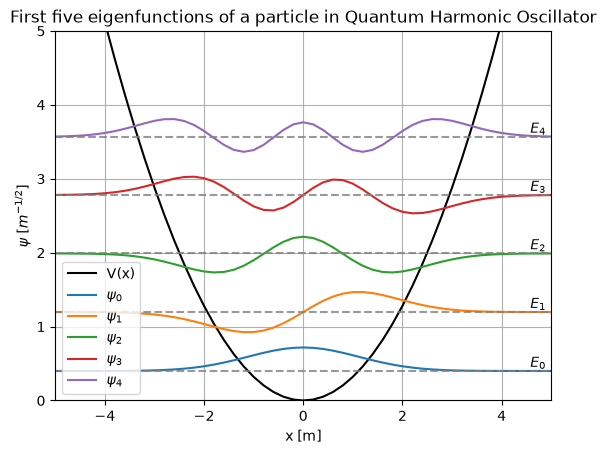

In [8]:
#consts
m = 1
hbar = 1
omega = 0.8

# creating our pos and potential arrays
points = 101
xs = np.linspace(-10,10, points)
Vxs = 0.5 * m * omega** 2 * xs**2

# now we get the hamiltonian of the system
hamiltonian_qhm = hamiltonian(xs, Vxs, m)

eigenvalues, eigenvectors = np.linalg.eigh(hamiltonian_qhm)

plt.plot(xs, Vxs, color = "black", label = "V(x)")

for n in range(5):
    E_n = eigenvalues[n]
    psi_n = eigenvectors[:,n]
    f_n = E_n + psi_n

    plt.plot(xs,f_n, label = fr"$\psi_{n}$")
    plt.axhline(y = E_n, color = "gray", linestyle = '--', alpha = 0.8)
    plt.text(4.9, E_n, fr"$E_{n}$", ha="right", va ="bottom")

plt.ylim(0,5)
plt.xlim(-5,5)
plt.legend(loc = "lower left")
plt.title("First five eigenfunctions of a particle in Quantum Harmonic Oscillator")
plt.xlabel("x [m]")
plt.ylabel(r"$\psi$ $[m^{-1/2}]$")
plt.grid()
plt.savefig("Problem1.png")
plt.show()

#### Problem 1 code summary
---

The ```hamiltonian``` function took any arbitrarily sized ```x_pos``` and ```potential_array``` so 


### Problem 2: Harmonic Oscillator in an Electric Field

The effective potential of an oscillator immersed in a uniform electric field is

$$
V(x) = \cfrac{1}{2}m\omega^2x^2 + qEx
$$

where $q$ is the particle's charge, and $E$ is the strength of the applied uniform electric field.

**(a)** Assume that the particle is an electron and it is immersed in a field of strength $E=q^{-1}$. Plot 100 eigenenergies of the resulting Hamiltonian, and compare it with the theoretical value of

$$
E_n = \hbar \omega \left(n+\cfrac{1}{2} \right) - \cfrac{q^2 E^2}{2m \omega^2}
$$

Did you get the expected result? Why or why not?

**(b)** Plot the potential and the probability density of the ground state. Does the plot make sense? 

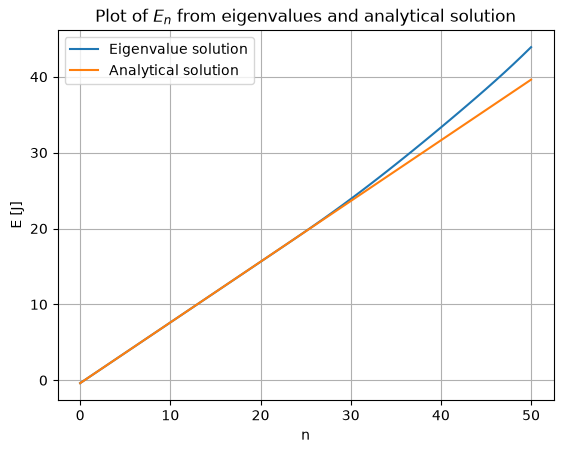

In [14]:
# code here

# NOTE: only plot 50 eigenenergies

# consts
m = 1
h = 1
omega = 0.8

# since E = 1/q, qEx = 1

# creating our arrays
points = 1001
xs_E = np.linspace(-10,10, points)
Vxs_E = (0.5 * m * omega**2 * xs_E**2) + xs_E

hamiltonian_qhm_efield = hamiltonian(xs_E, Vxs_E, m)

eigenvalues2, eigenvectors2 = np.linalg.eigh(hamiltonian_qhm_efield)

# define analytical function
def E_n_analytic(n):
    return h * omega * (n + 0.5) - 1 / (2 * m * omega**2)

# solve for E_0 until E_50
ns = np.arange(0,51)
Ens_analytical = E_n_analytic(ns)

plt.plot(eigenvalues2[0:51], label = "Eigenvalue solution")
plt.plot(Ens_analytical, label = "Analytical solution")
plt.ylabel("E [J]")
plt.xlabel("n")
plt.title(r"Plot of $E_n$ from eigenvalues and analytical solution")
plt.grid()
plt.legend()
plt.savefig("Problem2_1.png")
plt.show()

In [19]:
# grab our ground state from eigenvectors 2
ground_state = eigenvectors2[:,0]

# normalize, the area under the curve of the psi mod square of wavefunction should be 1
area = np.trapz(np.abs(ground_state)**2, xs_E)
ground_state_normalized = ground_state / np.sqrt(area)

ground_state_pd = np.abs(ground_state_normalized)**2

# Plotting
plt.plot(xs_E, Vxs_E, color = "black", label = r"$V(x)$ [J]")
plt.plot(xs_E, ground_state_pd, label = r"$|\psi|^2$")
plt.fill_between(xs_E, ground_state_pd, color="skyblue", alpha=0.4)
plt.ylim(-1,2)
plt.xlim(-5,5)
plt.legend()
plt.title("Ground state of particle in a harmonic oscillator under an electric field")
plt.ylabel(r"$|\psi|^2$ $[1/m]$")
plt.xlabel("x [m]")
plt.grid()
plt.savefig("Problem2_2.png")
plt.show()

# checking if area under PDF is 1
area = np.trapz(ground_state_pd, xs_E)
print(f"Area under the curve: {area:.6f}")
print(f"Ground state energy: {eigenvalues2[0]}")

AttributeError: module 'numpy' has no attribute 'trapz'

#### Problem 2 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---

## Section 3 (Notes)

### Some codes for solving matrix problems

* solving matrix equations ($\bf{A}\vec{x} = \vec{b}$) -> `np.linalg.solve`
* LU-decomposition ($\bf{A} = \bf{L}\bf{U}$) -> `scipy.linalg.lu`
* matrix inversion ($\bf{A}^{-1}$) -> `np.linalg.inv`
* QR-decomposition ($\bf{A} = \bf{Q}\bf{R}$) -> `scipy.linalg.qr`
* eigenvalue problem ($\bf{A}\vec{x} = \lambda \vec{x}$) -> `np.linalg.eig`

Solving matrix problems by themselves isn't difficult. There is an abundance of linear algebra libraries that are ready to use: from the battle-tested ones (the classic [BLAS](https://www.netlib.org/blas/) and [LAPACK](https://www.netlib.org/lapack/)), HPC tools for large problems ([ScaLAPACK](https://netlib.org/scalapack/)), to hardware-accelerated ones often with GPUs ([cuBLAS](https://docs.nvidia.com/cuda/cublas/index.html) and [cuSolver](https://docs.nvidia.com/cuda/cusolver/index.html) for NVIDIA). 

The hardest part is actually composing the matrix. How do you transform a physical problem into a linear algebra problem?

* Circuit: https://personal.math.vt.edu/embree/cmda3606/chapter2.pdf
* Embree [main notes](https://personal.math.vt.edu/embree/cmda3606notes.pdf) + [lab manual](https://personal.math.vt.edu/embree/labman.pdf)